# NORMALISASI Z-SCORE #

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# DATA
# ==============================================================================
df_zscore = pd.read_csv('dataset_fasilitas_kesehatan_skripsi_kedua.csv')
kolom_string = [
    'kode_provinsi',
    'kode_kabupaten_kota',
]

df_zscore[kolom_string] = df_zscore[kolom_string].astype(str)

kolom_numerik = [
    col for col in df_zscore.select_dtypes(include='number').columns
    if col != 'tahun'
]

print("=========== DATA ===========")
df_zscore

=========== DATA ===========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,9,15,347,141,619,41173,292,592938
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,12,19,519,129,990,46778,479,962125
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,3,19,384,227,792,40464,285,748432
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,14,18,609,263,1098,114929,507,1109547
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,6,18,540,233,837,65232,392,1230159
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,8,0,1,0,261,18844,287,213469
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,6,0,4,0,396,16010,129,142272
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,6,0,5,0,521,23764,756,201733
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,40,23,69,0,7446,851331,2299,3018022


In [2]:
# ==============================================================================
# STANDARDISASI Z-SCORE
# ==============================================================================
scaler = StandardScaler()

df_zscore[kolom_numerik] = scaler.fit_transform(df_zscore[kolom_numerik])

print("========== HASIL STANDARDISASI Z-SCORE ==========")
df_zscore

========== HASIL STANDARDISASI Z-SCORE ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675


* AGGLOMERATIVE HIERARCHICAL CLUSTERING


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score)

In [4]:
#===============================================================================
# DATA
#===============================================================================

df_zscore_ahc = df_zscore.copy()
df_zscore_ahc

,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573
...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675


In [5]:
#===============================================================================
# 1. HITUNG MATRIKS JARAK/LINKAGE
#===============================================================================

linkage_matrix = linkage(
    df_zscore_ahc[kolom_numerik],
    method="ward",
    metric="euclidean"
)

print("========== HASIL LINKAGE MATRIX ==========")
linkage_matrix

========== HASIL LINKAGE MATRIX ==========


array([[3.70000000e+01, 7.50000000e+01, 8.77882731e-02, 2.00000000e+00],
       [5.60000000e+01, 9.40000000e+01, 9.09945299e-02, 2.00000000e+00],
       [2.40000000e+01, 6.20000000e+01, 9.80461767e-02, 2.00000000e+00],
       ...,
       [4.98000000e+02, 5.26000000e+02, 2.10869308e+01, 2.17000000e+02],
       [5.27000000e+02, 5.28000000e+02, 2.83322111e+01, 2.64000000e+02],
       [5.19000000e+02, 5.29000000e+02, 3.20316649e+01, 2.66000000e+02]])

In [6]:
#===============================================================================
# 2. PASANGAN CLUSTER TERDEKAT
#===============================================================================

linkage_df = pd.DataFrame(
    linkage_matrix,
    columns=[
        "Cluster 1",
        "Cluster 2",
        "Jarak",
        "Jumlah Anggota"
    ]
)

print("========== PASANGAN CLUSTER TERDEKAT ==========")
linkage_df

========== PASANGAN CLUSTER TERDEKAT ==========


,Cluster 1,Cluster 2,Jarak,Jumlah Anggota
0,37.0,75.0,0.087788,2.0
1,56.0,94.0,0.090995,2.0
2,24.0,62.0,0.098046,2.0
3,27.0,65.0,0.101925,2.0
4,32.0,70.0,0.114630,2.0
...,...,...,...,...
260,523.0,524.0,15.255080,168.0
261,511.0,525.0,17.901328,47.0
262,498.0,526.0,21.086931,217.0
263,527.0,528.0,28.332211,264.0


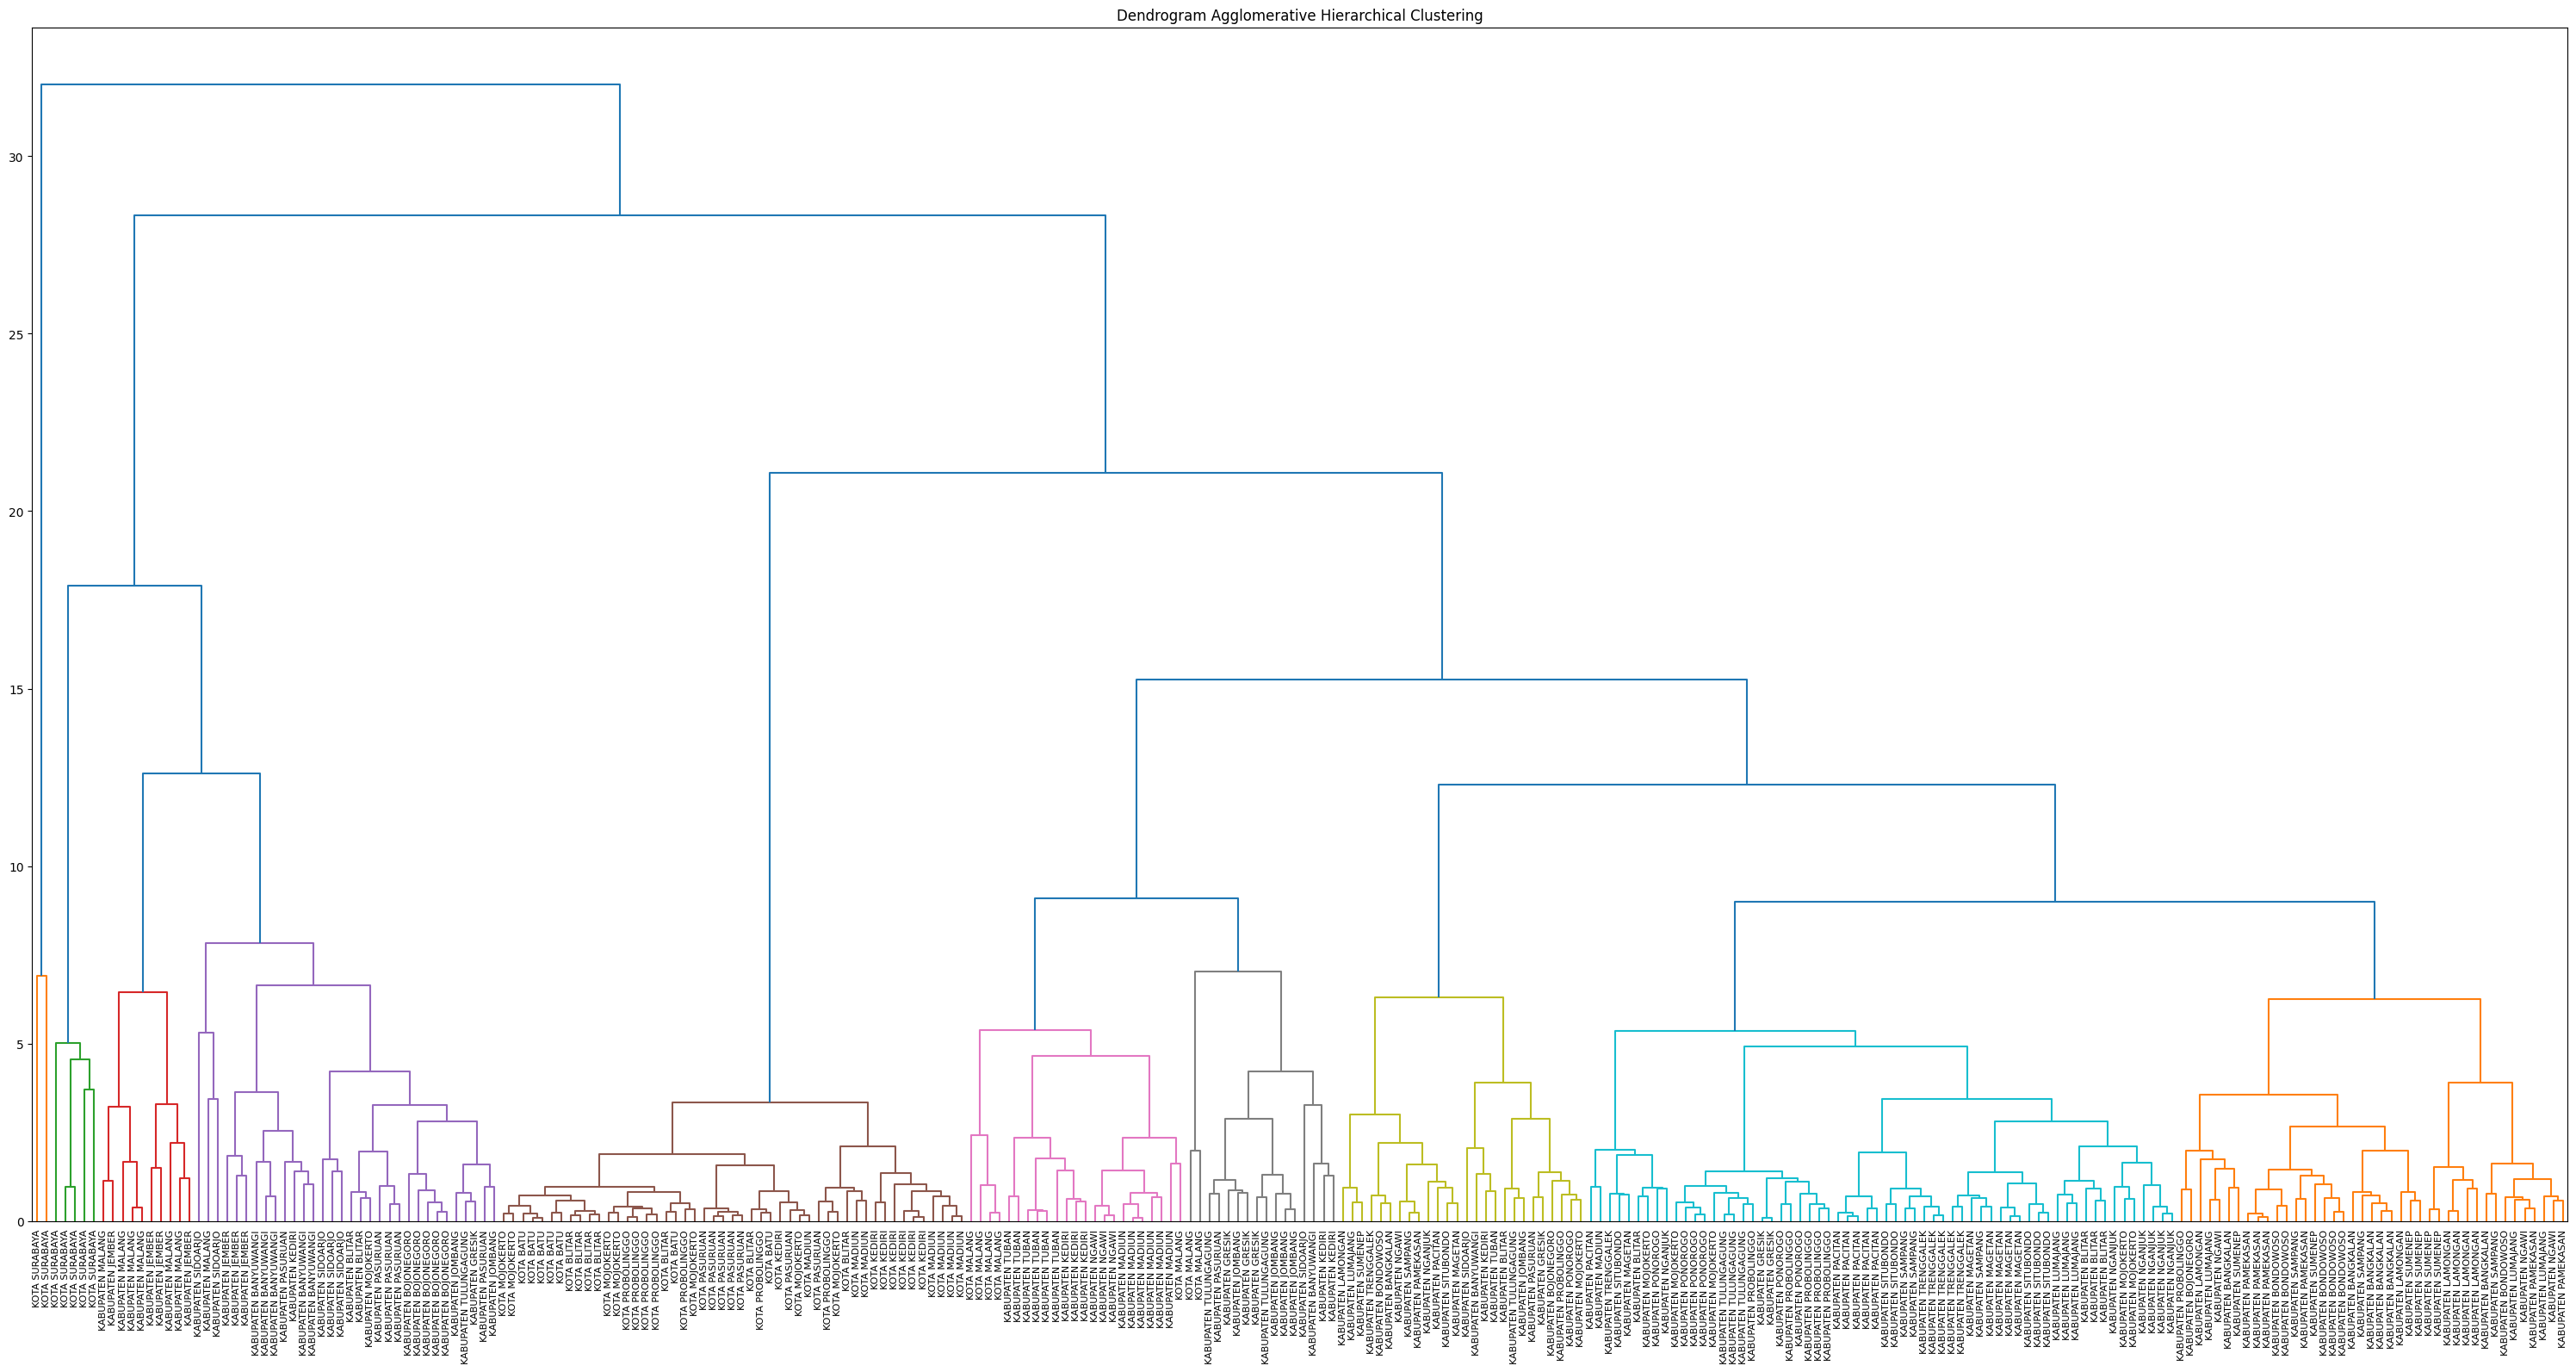

In [7]:
#===============================================================================
# 2.1. DENDROGRAM
#===============================================================================

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels=df_zscore_ahc["nama_kabupaten_kota"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

#plt.axhline(y=8, color="r", linestyle="--", linewidth=1)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()

In [8]:
#===============================================================================
# 3. EVALUASI CLUSTER
#===============================================================================

hasil_evaluasi = []

for k in range(2,11):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
        metric="euclidean"
    )

    cluster = model.fit_predict(df_zscore_ahc[kolom_numerik])
    
    silhouette = silhouette_score(df_zscore_ahc[kolom_numerik], cluster)
    dbi = davies_bouldin_score(df_zscore_ahc[kolom_numerik], cluster)
    chi = calinski_harabasz_score(df_zscore_ahc[kolom_numerik], cluster)
    
    hasil_evaluasi.append({
    'Jumlah Cluster (K)': k,
    'Silhouette Score': silhouette,
    'Davies-Bouldin Index': dbi,
    'Calinski-Harabasz Index': chi
    })
    
hasil_evaluasi = pd.DataFrame(hasil_evaluasi)
    
print("========== HASIL EVALUASI JUMLAH CLUSTER==========")
display(hasil_evaluasi.round(4))

========== HASIL EVALUASI JUMLAH CLUSTER==========


,Jumlah Cluster (K),Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,2,0.8106,0.3473,83.8618
1,3,0.3633,1.0510,99.0746
2,4,0.2572,1.0976,100.1431
3,5,0.2646,1.0850,101.8260
4,6,0.2842,1.1170,102.8259
5,7,0.3031,1.0975,101.4530
6,8,0.3241,1.1070,103.3313
7,9,0.3266,1.0756,99.8372
8,10,0.2803,1.1635,98.3115


In [9]:
# --------------------------
# 3.1. K OPTIMAL
# --------------------------

print("========== K OPTIMAL ==========")


k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Silhouette Score'].idxmax(), 'Jumlah Cluster (K)']
print("1. K Optimal berdasarkan Silhouette Score:", k_optimal)


========== K OPTIMAL ==========
1. K Optimal berdasarkan Silhouette Score: 2


In [10]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Davies-Bouldin Index'].idxmin(), 'Jumlah Cluster (K)']
print("2. K Optimal berdasarkan Davies-Bouldin Index:", k_optimal)

2. K Optimal berdasarkan Davies-Bouldin Index: 2


In [11]:
k_optimal = hasil_evaluasi.loc[hasil_evaluasi['Calinski-Harabasz Index'].idxmax(), 'Jumlah Cluster (K)']
print("3. K Optimal berdasarkan Calinski-Harabasz Index:", k_optimal)

3. K Optimal berdasarkan Calinski-Harabasz Index: 8


_Pemotongan klaster yang diggunakan_

In [12]:
k = 2

In [13]:
#===============================================================================
# 4. CLUSTERING DENGAN K OPTIMAL
#===============================================================================

ahc = AgglomerativeClustering(
    n_clusters=k,
    linkage="ward",
    metric="euclidean"
)

ahc.fit(df_zscore_ahc[kolom_numerik])

AgglomerativeClustering()

In [14]:
#===============================================================================
# 5. SIMPAN LABEL CLUSTER
#===============================================================================

print("========== LABEL CLUSTER ==========")
df_hasil = df_zscore_ahc.copy()
df_hasil["cluster_ahc"] = ahc.labels_ + 1
df_hasil

========== LABEL CLUSTER ==========


,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,tahun,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk,cluster_ahc
0,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2018,-0.054319,-0.101171,-0.663895,-0.157692,-0.552015,-0.650976,-0.423431,-0.737864,1
1,35,JAWA TIMUR,3502,KABUPATEN PONOROGO,2018,0.259788,0.308129,-0.269216,-0.183849,-0.298458,-0.614644,-0.394936,-0.182574,1
2,35,JAWA TIMUR,3503,KABUPATEN TRENGGALEK,2018,-0.682533,0.308129,-0.578993,0.029762,-0.433780,-0.655572,-0.424498,-0.503987,1
3,35,JAWA TIMUR,3504,KABUPATEN TULUNGAGUNG,2018,0.469192,0.205804,-0.062697,0.108231,-0.224647,-0.172882,-0.390669,0.039162,1
4,35,JAWA TIMUR,3505,KABUPATEN BLITAR,2018,-0.368426,0.205804,-0.221028,0.042840,-0.403025,-0.495023,-0.408193,0.220573,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,35,JAWA TIMUR,3575,KOTA PASURUAN,2024,-0.159021,-1.636045,-1.457843,-0.465030,-0.796687,-0.795715,-0.424193,-1.308618,1
262,35,JAWA TIMUR,3576,KOTA MOJOKERTO,2024,-0.368426,-1.636045,-1.450959,-0.465030,-0.704423,-0.814085,-0.448269,-1.415705,1
263,35,JAWA TIMUR,3577,KOTA MADIUN,2024,-0.368426,-1.636045,-1.448665,-0.465030,-0.618992,-0.763823,-0.352727,-1.326270,1
264,35,JAWA TIMUR,3578,KOTA SURABAYA,2024,3.191450,0.717429,-1.301807,-0.465030,4.113840,4.600555,-0.117605,2.909675,1


In [15]:
#================================================================================
# 5.1. JUMLAH ANGGOTA CLUSTER
#================================================================================

jumlah_cluster = (
    df_hasil["cluster_ahc"]
    .value_counts()
    .sort_index()
)

display(jumlah_cluster)

cluster_ahc
1    264
2      2
Name: count, dtype: int64

In [16]:
#===============================================================================
# 5.2. PROFIL CLUSTER
#===============================================================================
profil_cluster = (
    df_hasil
    .groupby("cluster_ahc")[kolom_numerik]
    .mean()
)

display(profil_cluster)

,pelayanan_non_rawat_inap,pelayanan_rawat_inap,jumlah_bidan,jumlah_dokter,jumlah_perawat,jumlah_penyakit_tidak_menular,jumlah_penyakit_menular,jumlah_penduduk
cluster_ahc,,,,,,,,
1,-0.024971,-0.004660,-0.023862,-0.074781,-0.047268,-0.009904,-0.070745,-0.021603
2,3.296153,0.615104,3.149809,9.871105,6.239343,1.307285,9.338377,2.851596


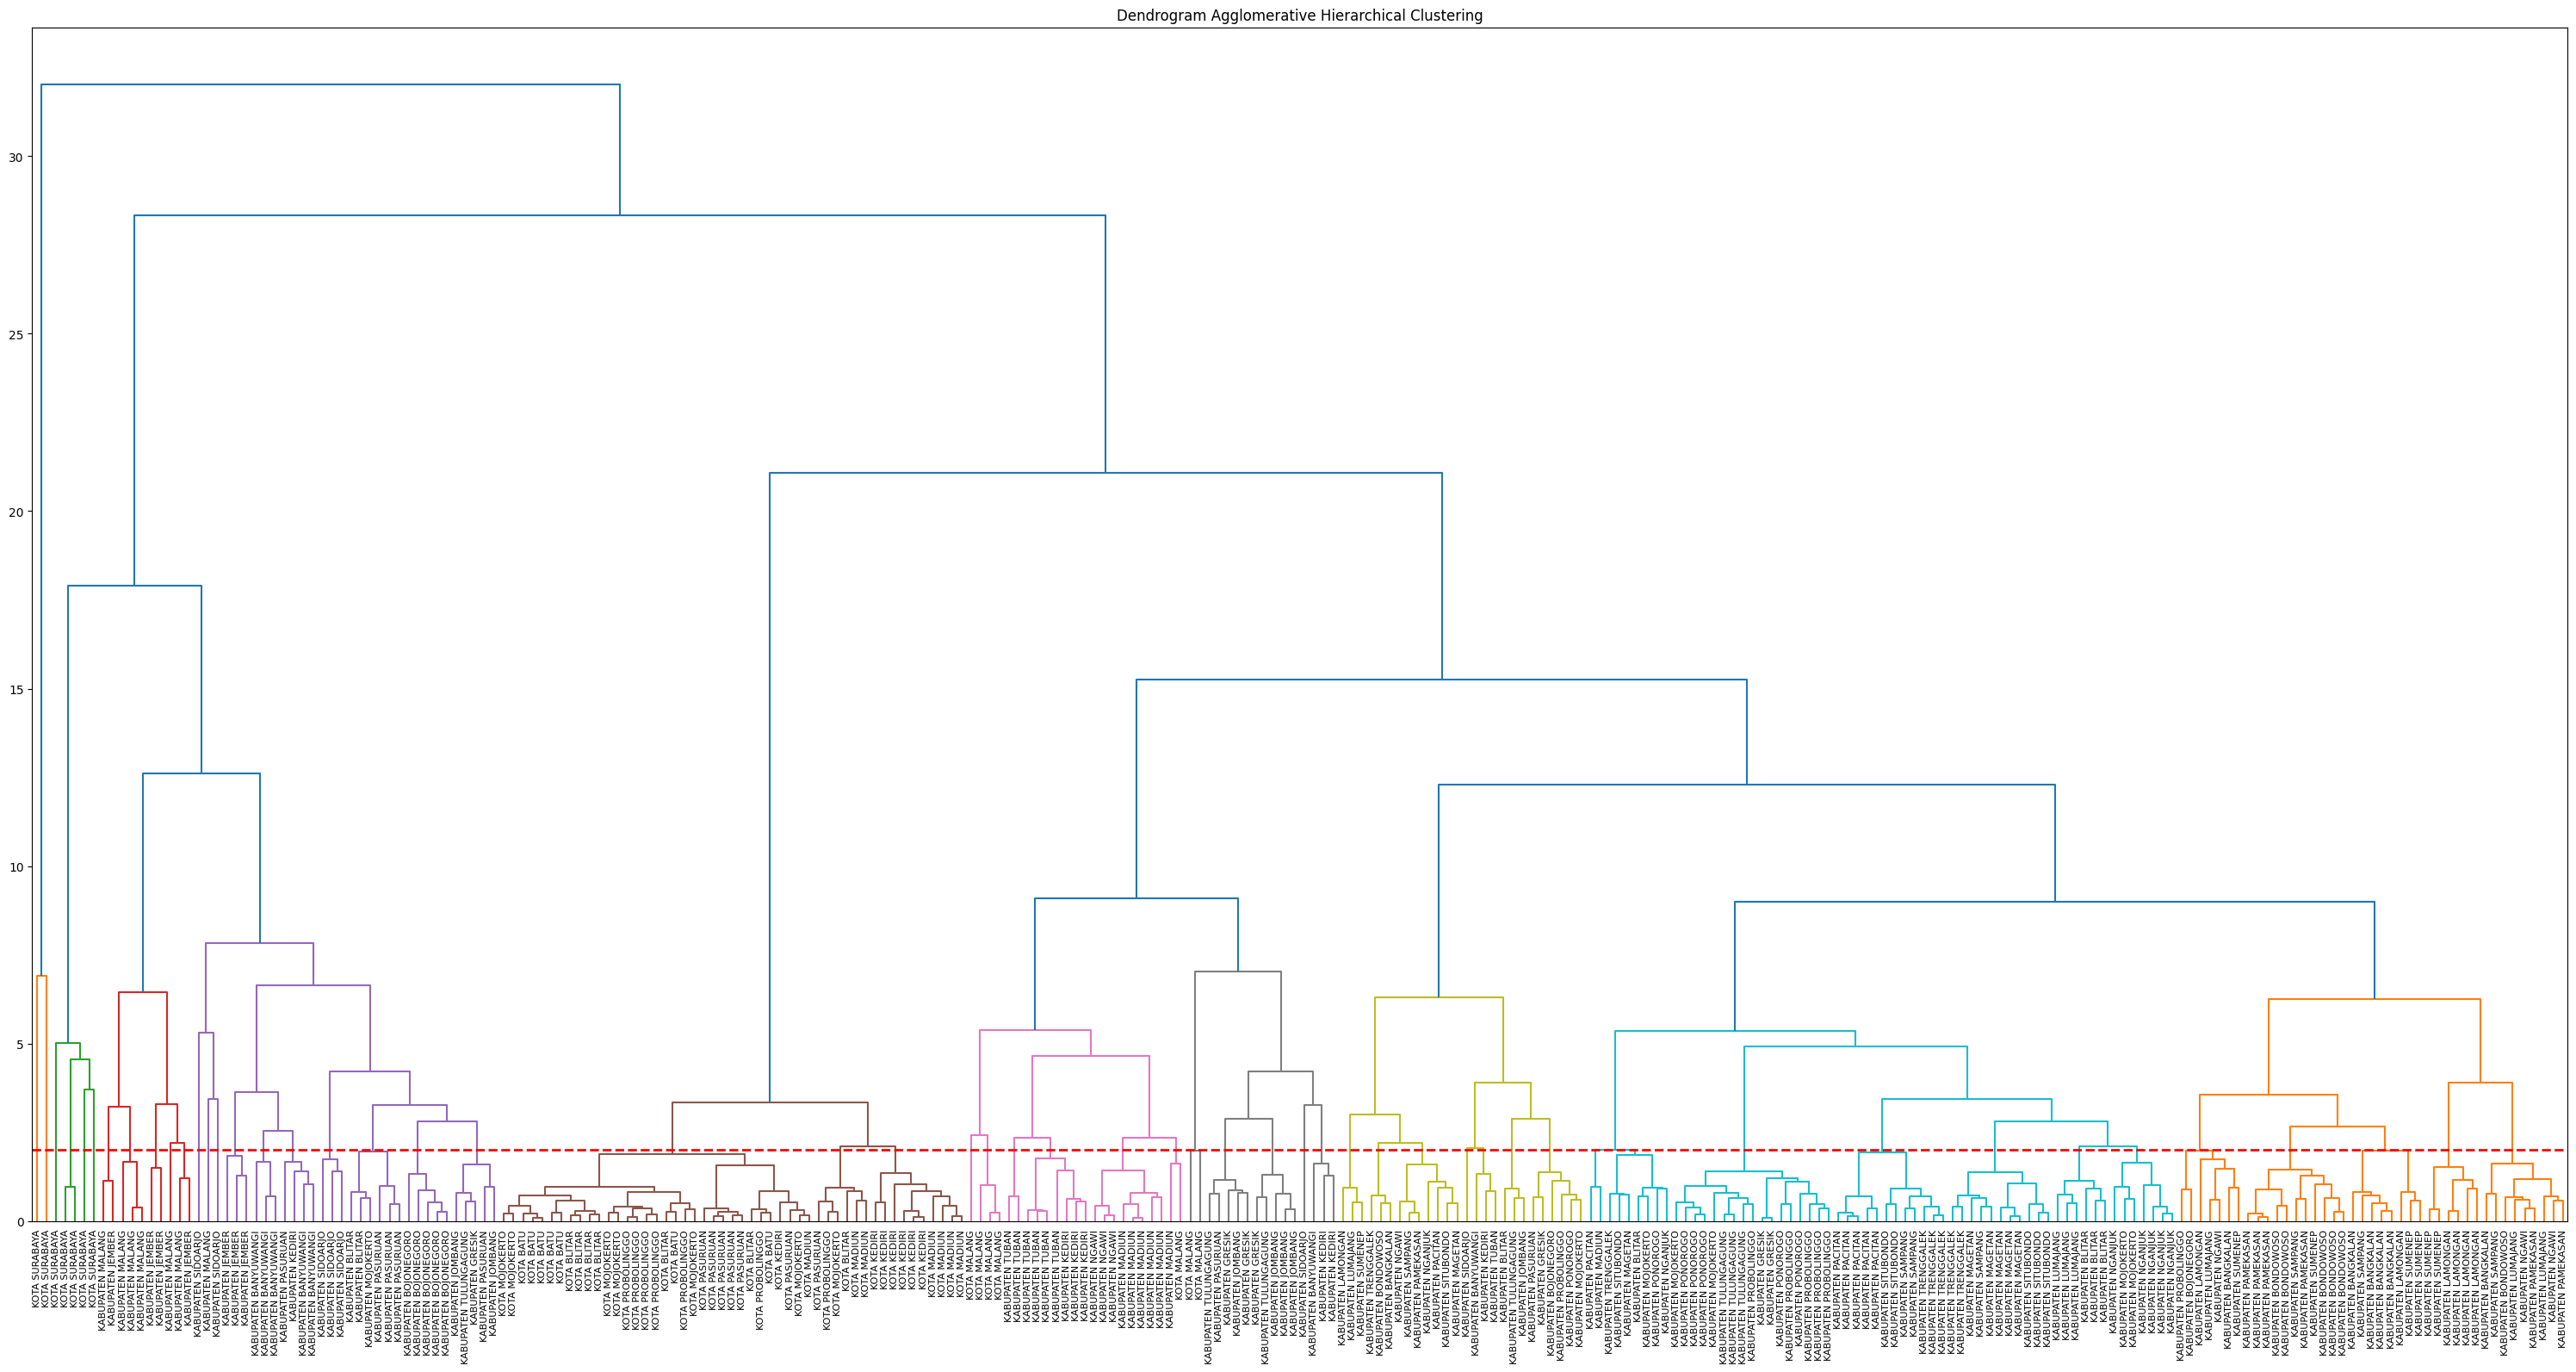

In [17]:

plt.figure(figsize=(38,18))

dendrogram(
    linkage_matrix,
    color_threshold=8,
    labels=df_zscore_ahc["nama_kabupaten_kota"].values,
    leaf_rotation=90,
    leaf_font_size=8,
    show_leaf_counts=True,
)

plt.axhline(y=2, color="r", linestyle="--", linewidth=2)
plt.title("Dendrogram Agglomerative Hierarchical Clustering")

plt.show()